# United States Congress - Measures Introduced and Enacted and Time in Session
This dataset comparse the amount of bills introducted in Congress over the amount of time spent in session.
It includes data going back to 1971; each measure introduced is categorized as a bill or a joint resolution.
Each measure enacted is seperated by private and public law changes.
Each chamber of the Congress gives information on days, hours, and the ratio of time in session.

In [1]:
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# Might be relevant for some commands
print(f"Pandas Version: {pd.__version__}")

Pandas Version: 3.0.1


In [3]:
with sqlite3.connect("../datasets/414.db") as con:
    df = pd.read_sql("SELECT * FROM congress_measures", con)

In [4]:
df.head()

,congress,years,section,item,value
0,92d,1971-72,National,Measures introduced,22969.0
1,93d,1973-74,National,Measures introduced,23396.0
2,94th,1975-76,National,Measures introduced,21096.0
3,95th,1977-78,National,Measures introduced,19387.0
4,96th,1979-80,National,Measures introduced,12583.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   congress  240 non-null    str    
 1   years     240 non-null    str    
 2   section   240 non-null    str    
 3   item      240 non-null    str    
 4   value     240 non-null    float64
dtypes: float64(1), str(4)
memory usage: 9.5 KB


## Relationship Between Number of Measures and Time Spend in Session

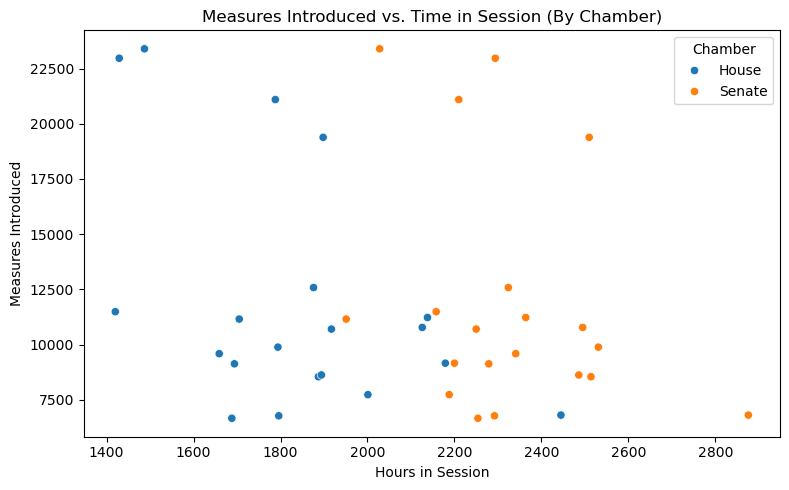

In [6]:
measures = df[df["item"] == "Measures introduced"][["congress", "value"]].rename(
    columns={"value": "measures_introduced"}
)

hours = df[
    (df["item"] == "Number of hours") & (df["section"].isin(["House", "Senate"]))
][["congress", "section", "value"]].rename(
    columns={"value": "hours_in_session", "section": "Chamber"}
)

plot_df = hours.merge(measures, on="congress")

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=plot_df,
    x="hours_in_session",
    y="measures_introduced",
    hue="Chamber",
    ax=ax,
)
ax.set_xlabel("Hours in Session")
ax.set_ylabel("Measures Introduced")
ax.set_title("Measures Introduced vs. Time in Session (By Chamber)")
plt.tight_layout()

plt.savefig("measures_vs_time.png", dpi=300)
plt.show()